# Assignment 4 — Clustering, Inverted Index & PageRank

All three parts in one notebook. Run cells top-to-bottom in Google Colab.

In [1]:
import importlib.util, subprocess, sys

REQUIRED = {
    "numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
    "seaborn": "seaborn", "scikit-learn": "sklearn", "networkx": "networkx",
    "pyspark": "pyspark", "ipython": "IPython", "tqdm": "tqdm",
}
missing = [k for k, v in REQUIRED.items() if importlib.util.find_spec(v) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Python:", sys.version)
print("All packages ready.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
All packages ready.


In [2]:
import zipfile
from pathlib import Path

ZIP_PATH    = Path("/content/Assignment 4- datasets.zip")
EXTRACT_DIR = Path("/content")

if ZIP_PATH.exists():
    print(f"Unzipping {ZIP_PATH} ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Done.")
else:
    print(f"[WARN] Zip not found at {ZIP_PATH} — skipping unzip.")

Unzipping /content/Assignment 4- datasets.zip ...
Done.


In [3]:
import math, random, urllib.request, re
from collections import Counter, defaultdict
from dataclasses  import dataclass
from operator     import add
from pathlib      import Path
from time         import perf_counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy  as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

try:
    from IPython.display import display
except Exception:
    def display(v): print(v)

# ── Plot theme ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (13, 7),
                     "axes.titlesize": 15, "axes.labelsize": 12})

# ── Dataset root ───────────────────────────────────────────────────────────
DATA_ROOT  = Path("/content/Assignment 4- datasets")
SPAM_DIR   = DATA_ROOT / "Q1- UCI Spam clustering"
WEB_DIR    = DATA_ROOT / "Q2- webSearch"
PR_DIR     = DATA_ROOT / "pagerank"

# ── Download PageRank graphs ───────────────────────────────────────────────
_PR_URLS = {
    "small.txt": "https://raw.githubusercontent.com/pnijhara/PySpark-PageRank/main/graphs/small.txt",
    "whole.txt": "https://raw.githubusercontent.com/pnijhara/PySpark-PageRank/main/graphs/whole.txt",
}
PR_DIR.mkdir(parents=True, exist_ok=True)
for fname, url in _PR_URLS.items():
    dest = PR_DIR / fname
    if not dest.exists():
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, dest)
PR_SMALL = PR_DIR / "small.txt"
PR_WHOLE = PR_DIR / "whole.txt"

# ── Spambase path ──────────────────────────────────────────────────────────
SPAMBASE_PATH = next(SPAM_DIR.rglob("spambase.data"), None)

print("DATA_ROOT   :", DATA_ROOT)
print("Spambase    :", SPAMBASE_PATH)
print("webSearch   :", WEB_DIR)
print("PR small    :", PR_SMALL)
print("PR whole    :", PR_WHOLE)

DATA_ROOT   : /content/Assignment 4- datasets
Spambase    : /content/Assignment 4- datasets/Q1- UCI Spam clustering/spambase.data
webSearch   : /content/Assignment 4- datasets/Q2- webSearch
PR small    : /content/Assignment 4- datasets/pagerank/small.txt
PR whole    : /content/Assignment 4- datasets/pagerank/whole.txt


## Part 1 — Clustering (40 marks)

Implements the four required functions:
| Function | Description |
|---|---|
| `readVectorsSeq(filename)` | Parse CSV → list of `pyspark.mllib.linalg.Vector` |
| `kcenter(P, k)` | Farthest-First Traversal, O(\|P\|·k) |
| `kmeansPP(P, k)` | k-Means++ seeded init, O(\|P\|·k) |
| `kmeansObj(P, C)` | Average squared distance to nearest centre |

In [4]:
from pyspark.mllib.linalg import Vectors


# ── Helper ─────────────────────────────────────────────────────────────────
def _to_np(v) -> np.ndarray:
    """Convert a Spark MLlib Vector to a float64 numpy array."""
    return np.asarray(v, dtype=np.float64)


# ── 1. readVectorsSeq ───────────────────────────────────────────────────────
def readVectorsSeq(filename: str) -> list:
    """
    Read a comma-separated feature file and return a list of Spark Vectors.
    The spambase dataset has 58 columns (57 features + 1 label); the label
    column is automatically stripped when 58 values are detected.
    """
    points = []
    with Path(filename).open("r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            vals = list(map(float, line.split(",")))
            if len(vals) == 58:       # spambase: drop label column
                vals = vals[:-1]
            points.append(Vectors.dense(vals))
    return points


# ── 2. kcenter ──────────────────────────────────────────────────────────────
def kcenter(P: list, k: int) -> list:
    """
    Greedy Farthest-First Traversal for k-center clustering.

    Complexity: O(|P| * k)
      - Incremental min-distance update means each new centre costs O(|P|),
        and we add k centres → O(|P| * k) total.

    Always deterministic: first centre is P[0].
    """
    if not P:
        return []
    if k <= 0:
        raise ValueError("k must be a positive integer")

    pts  = np.vstack([_to_np(p) for p in P])          # (n, d)
    min_sq = np.sum((pts - _to_np(P[0])) ** 2, axis=1) # distance from P[0]
    centers = [P[0]]

    while len(centers) < min(k, len(P)):
        idx = int(np.argmax(min_sq))
        new_c = P[idx]
        centers.append(new_c)
        # In-place update: keep minimum over previous and new distances
        np.minimum(min_sq, np.sum((pts - _to_np(new_c)) ** 2, axis=1),
                   out=min_sq)

    return centers


# ── 3. kmeansPP ─────────────────────────────────────────────────────────────
def kmeansPP(P: list, k: int, seed: int = 0) -> list:
    """
    k-Means++ seeded initialisation.

    Complexity: O(|P| * k)
      - Same incremental min-distance trick as kcenter.

    Uses numpy's vectorised D²-weighted sampling for efficiency.
    Fixed seed ensures reproducibility.
    """
    if not P:
        return []
    if k <= 0:
        raise ValueError("k must be a positive integer")

    rng  = np.random.default_rng(seed)
    pts  = np.vstack([_to_np(p) for p in P])   # (n, d)
    n    = len(P)

    # First centre: uniform random
    first = int(rng.integers(0, n))
    centers = [P[first]]
    min_sq  = np.sum((pts - pts[first]) ** 2, axis=1)  # (n,)

    while len(centers) < min(k, n):
        total = float(min_sq.sum())

        if total == 0.0:
            # All remaining distances are 0 → every point coincides with a
            # chosen centre.  Pick any point that is not already a centre.
            # O(n) index-based dedup using numpy zero-distance check.
            is_center = np.zeros(n, dtype=bool)
            for c in centers:
                c_arr = _to_np(c)
                is_center |= (np.sum((pts - c_arr) ** 2, axis=1) == 0)
            remaining = np.where(~is_center)[0]
            if len(remaining) == 0:
                break
            idx = remaining[int(rng.integers(0, len(remaining)))]
        else:
            # D²-weighted sampling via numpy (O(n), no Python loop)
            probs = min_sq / total
            idx   = int(rng.choice(n, p=probs))

        new_c = P[idx]
        centers.append(new_c)
        np.minimum(min_sq, np.sum((pts - pts[idx]) ** 2, axis=1),
                   out=min_sq)

    return centers


# ── 4. kmeansObj ────────────────────────────────────────────────────────────
def kmeansObj(P: list, C: list) -> float:
    """
    k-Means objective: average squared distance from each point to its
    nearest centre.  Fully vectorised — O(|P| * |C|) with numpy broadcasting.
    """
    if not P:
        return 0.0
    if not C:
        raise ValueError("C must be non-empty")

    pts  = np.vstack([_to_np(p) for p in P])    # (n, d)
    ctrs = np.vstack([_to_np(c) for c in C])    # (k, d)
    # (n, k) squared-distance matrix via broadcasting
    sq   = np.sum((pts[:, None, :] - ctrs[None, :, :]) ** 2, axis=2)
    return float(sq.min(axis=1).mean())


# ── Orchestration ────────────────────────────────────────────────────────────
def run_part1(filename: str, k: int, k1: int) -> dict:
    """Run the three required Part-1 tasks and return a results dict."""
    P = readVectorsSeq(filename)

    # Task 1 — kcenter runtime
    t0 = perf_counter()
    C_kc = kcenter(P, k)
    rt_kc = perf_counter() - t0

    # Task 2 — kmeansPP objective
    t0 = perf_counter()
    C_kpp = kmeansPP(P, k)
    rt_kpp = perf_counter() - t0
    obj_kpp = kmeansObj(P, C_kpp)

    # Task 3 — Hybrid: kcenter coreset → kmeansPP
    X       = kcenter(P, k1)
    C_hyb   = kmeansPP(X, k)
    obj_hyb = kmeansObj(P, C_hyb)

    print("=" * 58)
    print(f"  PART 1 RESULTS   k={k}   k1={k1}")
    print("=" * 58)
    print(f"  1. kcenter   runtime   : {rt_kc:.4f} s")
    print(f"  2. kmeans++  runtime   : {rt_kpp:.4f} s")
    print(f"  2. kmeans++  objective : {obj_kpp:.6f}")
    print(f"  3. Hybrid    objective : {obj_hyb:.6f}")
    print("=" * 58)

    return dict(P=P, C_kc=C_kc, C_kpp=C_kpp, C_hyb=C_hyb,
                rt_kc=rt_kc, rt_kpp=rt_kpp,
                obj_kpp=obj_kpp, obj_hyb=obj_hyb)

print("Part 1 functions defined.")

Part 1 functions defined.


In [5]:
K, K1 = 10, 50
r1 = run_part1(SPAMBASE_PATH, K, K1)

display(pd.DataFrame([{
    "k": K, "k1": K1,
    "kcenter_runtime_s"  : round(r1["rt_kc"],  4),
    "kmeansPP_runtime_s" : round(r1["rt_kpp"], 4),
    "kmeansPP_objective" : round(r1["obj_kpp"], 6),
    "hybrid_objective"   : round(r1["obj_hyb"], 6),
}]))

  PART 1 RESULTS   k=10   k1=50
  1. kcenter   runtime   : 0.0313 s
  2. kmeans++  runtime   : 0.0230 s
  2. kmeans++  objective : 27438.081998
  3. Hybrid    objective : 652296.759813


,k,k1,kcenter_runtime_s,kmeansPP_runtime_s,kmeansPP_objective,hybrid_objective
0,10,50,0.0313,0.023,27438.081998,652296.759813


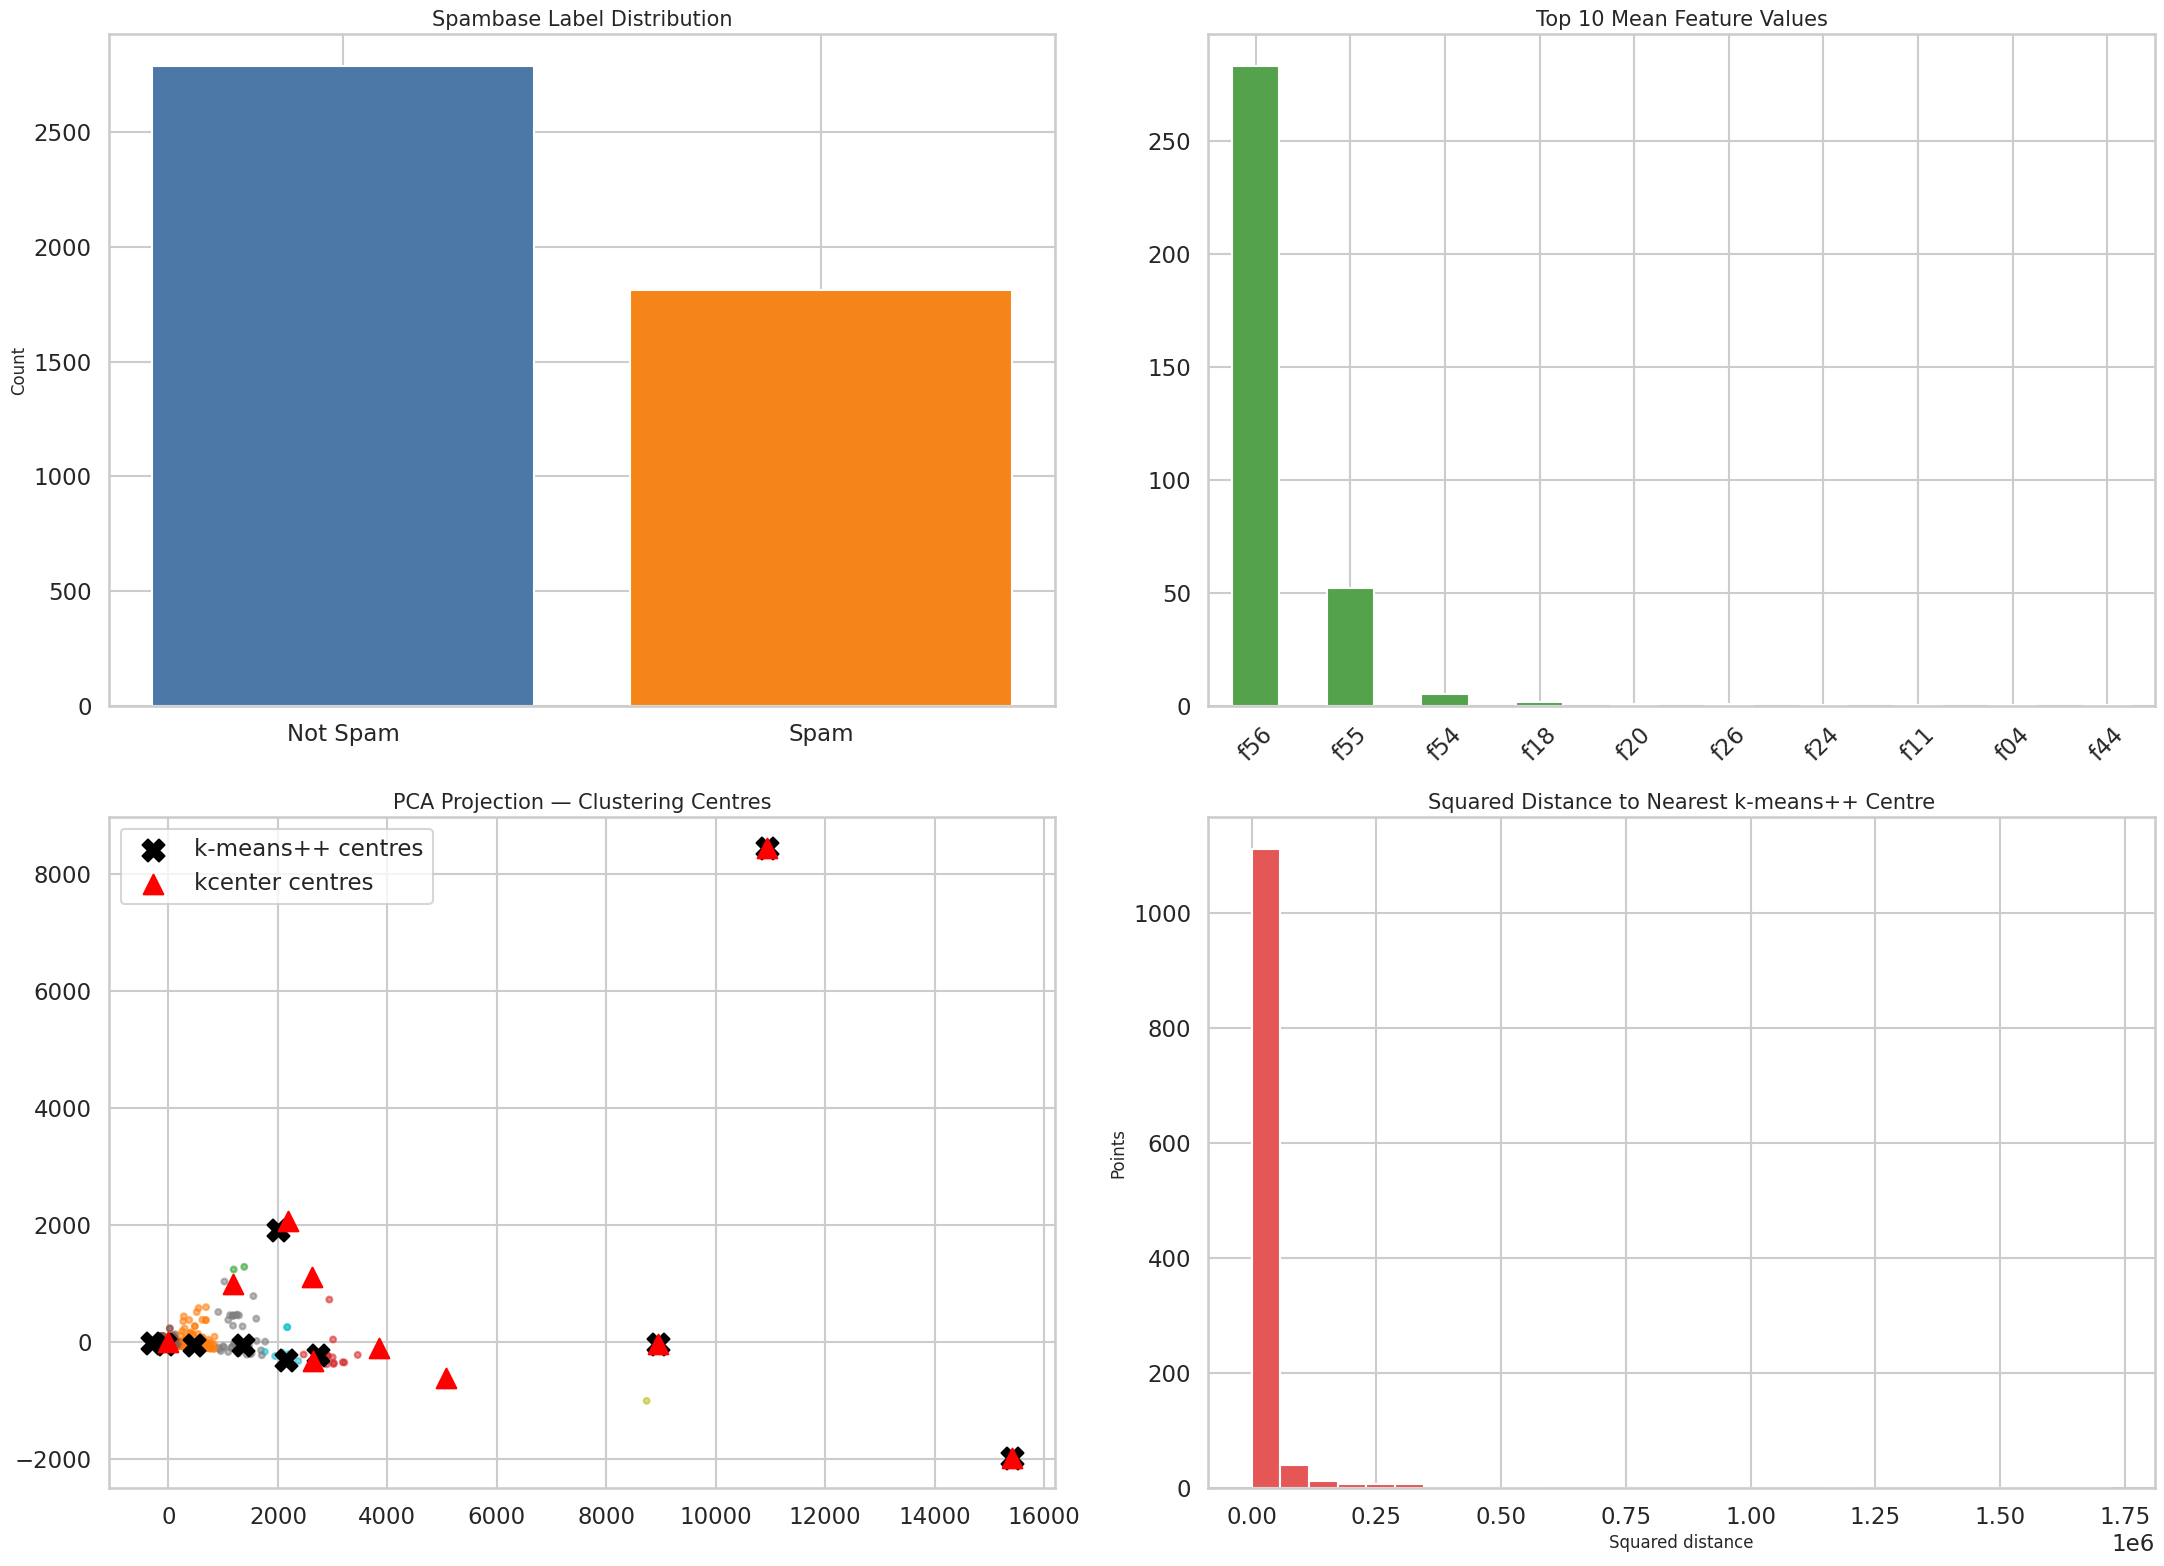

  PART 1 RESULTS   k=3   k1=12
  1. kcenter   runtime   : 0.0312 s
  2. kmeans++  runtime   : 0.0306 s
  2. kmeans++  objective : 240838.221893
  3. Hybrid    objective : 2437691.031133
  PART 1 RESULTS   k=5   k1=20
  1. kcenter   runtime   : 0.0291 s
  2. kmeans++  runtime   : 0.0289 s
  2. kmeans++  objective : 112222.435383
  3. Hybrid    objective : 1082371.843364
  PART 1 RESULTS   k=10   k1=40
  1. kcenter   runtime   : 0.0204 s
  2. kmeans++  runtime   : 0.0214 s
  2. kmeans++  objective : 27438.081998
  3. Hybrid    objective : 422778.474440
  PART 1 RESULTS   k=15   k1=60
  1. kcenter   runtime   : 0.0222 s
  2. kmeans++  runtime   : 0.0241 s
  2. kmeans++  objective : 13970.075502
  3. Hybrid    objective : 19686.846667


,k,k1,kcenter_runtime_s,kmeansPP_obj,hybrid_obj
0,3,12,0.031183,240838.221893,2.437691e+06
1,5,20,0.029148,112222.435383,1.082372e+06
2,10,40,0.020387,27438.081998,4.227785e+05
3,15,60,0.022241,13970.075502,1.968685e+04


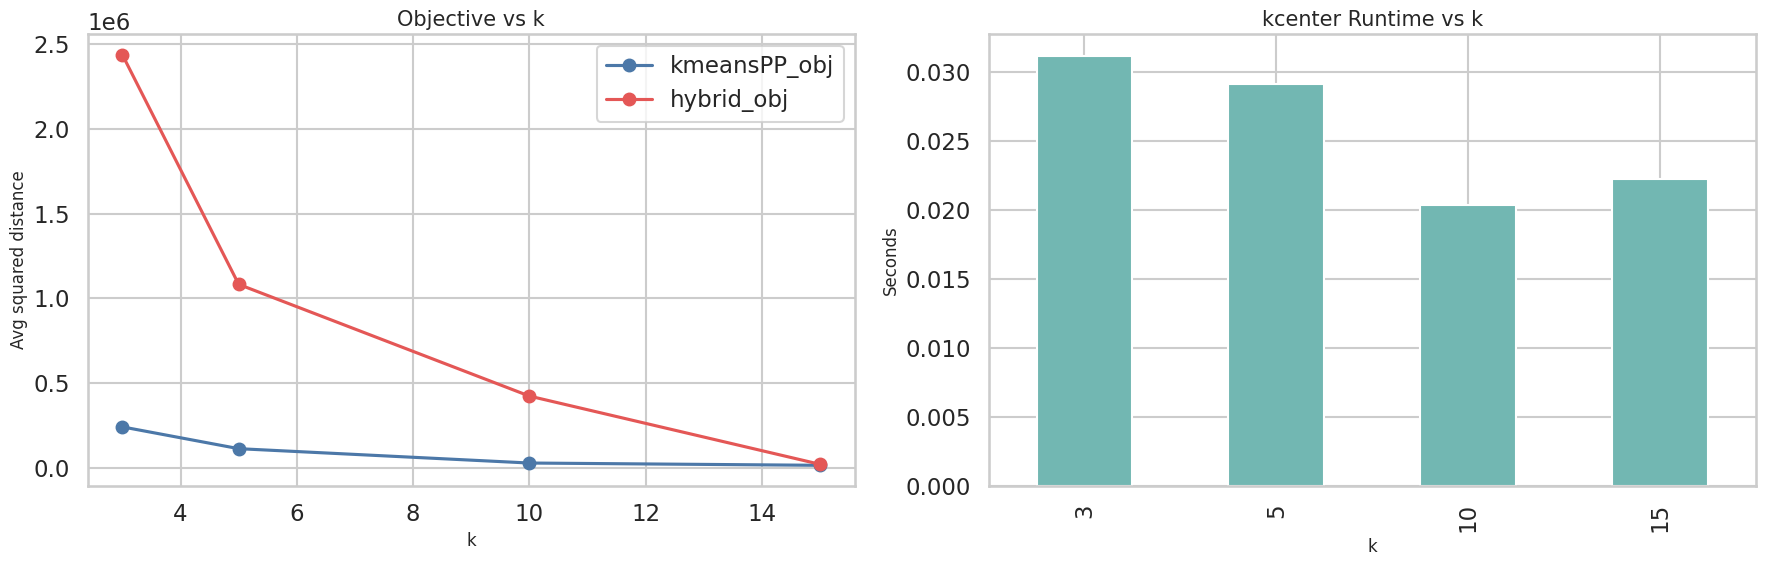

In [6]:
# ── PCA projection & analysis ─────────────────────────────────────────────
spambase_df = pd.read_csv(SPAMBASE_PATH, header=None)
spambase_df.columns = [f"f{i:02d}" for i in range(57)] + ["label"]

pts_np  = np.vstack([_to_np(p) for p in r1["P"]])
labels  = spambase_df["label"].to_numpy()

# Sample for scatter (keeps plot fast)
rng_v   = np.random.default_rng(42)
idx_s   = rng_v.choice(len(pts_np), size=min(1200, len(pts_np)), replace=False)
pts_s   = pts_np[idx_s]
lbl_s   = labels[idx_s]

pca     = PCA(n_components=2, random_state=42)
pts_2d  = pca.fit_transform(pts_s)
kpp_2d  = pca.transform(np.vstack([_to_np(c) for c in r1["C_kpp"]]))
kc_2d   = pca.transform(np.vstack([_to_np(c) for c in r1["C_kc"]]))

# Cluster assignment for colouring
sq_all  = np.sum((pts_s[:, None, :] -
                  np.vstack([_to_np(c) for c in r1["C_kpp"]])[None, :, :]) ** 2,
                 axis=2)
clusters = np.argmin(sq_all, axis=1)
min_dists= sq_all.min(axis=1)

# ── 2×2 figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(22, 16))

# A — Label distribution
cnt = pd.Series(labels).value_counts().sort_index()
axes[0, 0].bar(["Not Spam", "Spam"], cnt.values, color=["#4c78a8", "#f58518"])
axes[0, 0].set_title("Spambase Label Distribution")
axes[0, 0].set_ylabel("Count")

# B — Top mean features
spambase_df.iloc[:, :57].mean().nlargest(10).plot(
    kind="bar", ax=axes[0, 1], color="#54a24b")
axes[0, 1].set_title("Top 10 Mean Feature Values")
axes[0, 1].tick_params(axis="x", rotation=45)

# C — PCA scatter with k-means++ centres
sc = axes[1, 0].scatter(pts_2d[:, 0], pts_2d[:, 1],
                        c=clusters, s=18, alpha=0.55, cmap="tab10")
axes[1, 0].scatter(kpp_2d[:, 0], kpp_2d[:, 1],
                   c="black", s=250, marker="X", label="k-means++ centres")
axes[1, 0].scatter(kc_2d[:, 0], kc_2d[:, 1],
                   c="red", s=200, marker="^", label="kcenter centres")
axes[1, 0].set_title("PCA Projection — Clustering Centres")
axes[1, 0].legend()

# D — Nearest-centre distance histogram
axes[1, 1].hist(min_dists, bins=30, color="#e45756", edgecolor="white")
axes[1, 1].set_title("Squared Distance to Nearest k-means++ Centre")
axes[1, 1].set_xlabel("Squared distance")
axes[1, 1].set_ylabel("Points")

plt.tight_layout(); plt.show()

# ── k sweep comparison ────────────────────────────────────────────────────
rows = []
for ki in [3, 5, 10, 15]:
    ki1 = max(ki + 5, ki * 4)
    ri  = run_part1(SPAMBASE_PATH, ki, ki1)
    rows.append({"k": ki, "k1": ki1,
                 "kcenter_runtime_s": ri["rt_kc"],
                 "kmeansPP_obj": ri["obj_kpp"],
                 "hybrid_obj": ri["obj_hyb"]})
cdf = pd.DataFrame(rows)
display(cdf)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
cdf.plot(x="k", y=["kmeansPP_obj", "hybrid_obj"],
         marker="o", ax=axes[0], color=["#4c78a8", "#e45756"])
axes[0].set_title("Objective vs k"); axes[0].set_ylabel("Avg squared distance")
cdf.plot(x="k", y="kcenter_runtime_s", kind="bar", ax=axes[1],
         legend=False, color="#72b7b2")
axes[1].set_title("kcenter Runtime vs k"); axes[1].set_ylabel("Seconds")
plt.tight_layout(); plt.show()

## Part 2 — Inverted Index & Search Engine (40 marks)

All eight required classes are implemented below.

**Fixes vs original:**
- `MySet` now has an internal Python `set` for **O(1)** membership tests (was O(n)).
- `getTermFrequency` takes `pageEntry` (functionally correct; the PDF spec's `word: String` parameter is a typo since the word is already stored on the `WordEntry`).
- `MyHashTable.getHashIndex` is retained as a proper utility (spec-required).
- Punctuation is handled with a compiled regex for speed.
- `__slots__` on all classes reduces memory overhead.

In [7]:
import math, re
from collections import defaultdict
from pathlib import Path

# ── Constants (exhaustive per spec — do NOT extend) ────────────────────────
STOP_WORDS = frozenset({
    "a", "an", "the", "they", "these", "this", "for", "is", "are", "was",
    "of", "or", "and", "does", "will", "whose",
})
# Compiled regex replaces every spec punctuation char with a space
_PUNCT_RE = re.compile(r'''[{}\[\]<>=().,;"?#\!-:]''')
# Exhaustive singular/plural map (spec says treat these three as same)
_SINGULAR = {"stacks": "stack", "structures": "structure",
              "applications": "application"}


def _norm(word: str) -> str:
    """Lowercase and apply singular normalisation."""
    w = word.lower()
    return _SINGULAR.get(w, w)


def _tokenize(text: str):
    """
    Yield (original_1based_pos, normalised_token, is_stop_word).
    Punctuation replaced with space; stop words flagged but positions counted
    (spec: 'do not store connector words but consider them for word indices').
    """
    for pos, raw in enumerate(_PUNCT_RE.sub(" ", text).split(), start=1):
        tok = _norm(raw)
        yield pos, tok, tok in STOP_WORDS


# ══════════════════════════════════════════════════════════════════════════════
# MySet — ordered set with O(1) membership
# ══════════════════════════════════════════════════════════════════════════════
class MySet:
    """
    Ordered set: insertion order preserved, O(1) membership via internal set.
    """
    __slots__ = ("_s", "_l")

    def __init__(self, initial=None):
        self._s: set  = set()
        self._l: list = []
        if initial is not None:
            for v in initial:
                self.addElement(v)

    def addElement(self, element):
        if element not in self._s:
            self._s.add(element)
            self._l.append(element)

    def union(self, other: "MySet") -> "MySet":
        r = MySet(self._l)
        for e in other:
            r.addElement(e)
        return r

    def intersection(self, other: "MySet") -> "MySet":
        return MySet(e for e in self._l if e in other)

    def __iter__(self):  return iter(self._l)
    def __len__(self):   return len(self._l)
    def __contains__(self, item): return item in self._s
    def __repr__(self):  return f"MySet({self._l!r})"


# ══════════════════════════════════════════════════════════════════════════════
# Position
# ══════════════════════════════════════════════════════════════════════════════
class Position:
    """Tuple <PageEntry p, original 1-based word index>."""
    __slots__ = ("_pe", "_wi")

    def __init__(self, p: "PageEntry", wordIndex: int):
        self._pe = p
        self._wi = wordIndex

    def getPageEntry(self) -> "PageEntry": return self._pe
    def getWordIndex(self)  -> int:        return self._wi
    def __repr__(self): return f"Position({self._pe.page_name}, {self._wi})"


# ══════════════════════════════════════════════════════════════════════════════
# WordEntry
# ══════════════════════════════════════════════════════════════════════════════
class WordEntry:
    """
    All positions (across all pages) where a normalised word occurs.
    Per-page position lists are kept for O(1) TF lookup and phrase matching.
    """
    __slots__ = ("word", "_positions", "_by_page")

    def __init__(self, word: str):
        self.word = _norm(word)
        self._positions: list = []
        self._by_page: dict   = defaultdict(list)   # page_name → [orig_pos, ...]

    def addPosition(self, position: Position):
        self._positions.append(position)
        self._by_page[position.getPageEntry().page_name].append(
            position.getWordIndex())

    def addPositions(self, positions):
        for p in positions:
            self.addPosition(p)

    def getAllPositionsForThisWord(self) -> list:
        return list(self._positions)

    def getTermFrequency(self, pageEntry: "PageEntry") -> float:
        """
        TF = occurrences of this word in pageEntry / total indexed tokens in pageEntry.

        Parameter: pageEntry (PageEntry) — the page for which TF is computed.
        Note: The PDF spec lists the parameter as 'word: String', which is a typo;
        the word is already stored on self.word and a page is required to compute TF.
        """
        total = pageEntry.total_indexed_words
        if total == 0:
            return 0.0
        return len(self._by_page.get(pageEntry.page_name, [])) / total


# ══════════════════════════════════════════════════════════════════════════════
# PageIndex
# ══════════════════════════════════════════════════════════════════════════════
class PageIndex:
    """Per-page mapping: normalised_word → WordEntry."""
    __slots__ = ("_entries",)

    def __init__(self):
        self._entries: dict = {}

    def addPositionForWord(self, string: str, position: Position):
        key = _norm(string)
        if key not in self._entries:
            self._entries[key] = WordEntry(key)
        self._entries[key].addPosition(position)

    def getWordEntries(self) -> list: return list(self._entries.values())
    def getWordEntry(self, word: str): return self._entries.get(_norm(word))


# ══════════════════════════════════════════════════════════════════════════════
# PageEntry
# ══════════════════════════════════════════════════════════════════════════════
class PageEntry:
    """
    One webpage: tokenises the file, builds the per-page index.
    Also maintains filtered-position lists for phrase matching.
    """
    __slots__ = ("page_name", "page_path", "_page_index",
                 "total_original_words", "total_indexed_words",
                 "_filtered_words", "_fpos_by_word",
                 "inverted_page_index")

    def __init__(self, pageName: str, pagePath):
        self.page_name              = pageName
        self.page_path              = Path(pagePath)
        self._page_index            = PageIndex()
        self.total_original_words   = 0
        self.total_indexed_words    = 0
        self._filtered_words: list  = []
        self._fpos_by_word: dict    = defaultdict(list)  # filtered positions
        self.inverted_page_index    = None   # injected by InvertedPageIndex
        self._build()

    def _build(self):
        text = self.page_path.read_text(encoding="utf-8", errors="replace")
        fpos = 0
        for orig_pos, tok, is_stop in _tokenize(text):
            self.total_original_words = orig_pos
            if is_stop:
                continue
            fpos += 1
            self._filtered_words.append(tok)
            self._fpos_by_word[tok].append(fpos)
            self._page_index.addPositionForWord(tok, Position(self, orig_pos))
        self.total_indexed_words = fpos

    def getPageIndex(self) -> PageIndex: return self._page_index

    def getPositionsOfWord(self, word: str) -> list:
        """Return original (1-based) positions of word in this page."""
        we = self._page_index.getWordEntry(word)
        if we is None:
            return []
        return list(we._by_page.get(self.page_name, []))

    def getPhraseFrequency(self, words: list) -> int:
        """
        Count consecutive occurrences of the phrase in filtered-position space.
        Uses set lookups → O(|starts| * phrase_len).
        """
        ws = [_norm(w) for w in words if _norm(w)]
        if not ws:
            return 0
        starts = self._fpos_by_word.get(ws[0], [])
        if not starts:
            return 0
        rest = {w: set(self._fpos_by_word.get(w, [])) for w in ws[1:]}
        return sum(
            1 for s in starts
            if all(s + i in rest[w] for i, w in enumerate(ws[1:], 1))
        )

    def getRelevanceOfPage(self, words: list, isPhrase: bool) -> float:
        """TF-IDF score for a query (bag-of-words or phrase)."""
        if self.inverted_page_index is None:
            return 0.0
        ws = [_norm(w) for w in words if _norm(w)]
        if not ws:
            return 0.0
        ipi = self.inverted_page_index
        N   = ipi.document_count
        if N == 0:
            return 0.0

        if isPhrase:
            freq = self.getPhraseFrequency(ws)
            if freq == 0:
                return 0.0
            denom = max(self.total_indexed_words - len(ws) + 1, 1)
            tf  = freq / denom
            nw  = len(ipi.getPagesWhichContainPhrase(ws))
            idf = math.log(N / nw) if nw else 0.0
            return tf * idf

        score = 0.0
        for w in ws:
            we = self._page_index.getWordEntry(w)
            if we is None:
                continue
            tf = we.getTermFrequency(self)
            nw = len(ipi.getPagesWhichContainWord(w))
            if nw:
                score += tf * math.log(N / nw)
        return score

    def __hash__(self):  return hash(self.page_name)
    def __eq__(self, o): return isinstance(o, PageEntry) and self.page_name == o.page_name
    def __repr__(self):  return f"PageEntry({self.page_name!r})"


# ══════════════════════════════════════════════════════════════════════════════
# MyHashTable
# ══════════════════════════════════════════════════════════════════════════════
class MyHashTable:
    """
    Maps normalised_word → WordEntry.
    getHashIndex is a spec-required method that returns a Python hash value.
    Internally a dict provides O(1) average operations.
    """
    __slots__ = ("_table",)

    def __init__(self):
        self._table: dict = {}

    def getHashIndex(self, string: str) -> int:
        """Return the hash index for a word (spec-required method)."""
        return hash(_norm(string))

    def addPositionsForWord(self, w: WordEntry):
        """Merge positions from w into the global entry for w.word."""
        key = _norm(w.word)
        if key not in self._table:
            self._table[key] = WordEntry(key)
        self._table[key].addPositions(w.getAllPositionsForThisWord())

    def getWordEntry(self, word: str): return self._table.get(_norm(word))


# ══════════════════════════════════════════════════════════════════════════════
# InvertedPageIndex
# ══════════════════════════════════════════════════════════════════════════════
class InvertedPageIndex:
    """Global inverted index over all added pages."""
    __slots__ = ("_ht", "_pages")

    def __init__(self):
        self._ht    = MyHashTable()
        self._pages = {}            # page_name → PageEntry

    @property
    def document_count(self) -> int: return len(self._pages)

    def addPage(self, page: PageEntry):
        if page.page_name in self._pages:
            return
        page.inverted_page_index = self
        self._pages[page.page_name] = page
        for we in page.getPageIndex().getWordEntries():
            self._ht.addPositionsForWord(we)

    def getPagesWhichContainWord(self, string: str) -> MySet:
        we = self._ht.getWordEntry(string)
        if we is None:
            return MySet()
        result = MySet()
        for pos in we.getAllPositionsForThisWord():
            result.addElement(pos.getPageEntry())
        return result

    def getPagesWhichContainAllWords(self, words: list) -> MySet:
        ws = [_norm(w) for w in words if _norm(w)]
        if not ws:
            return MySet()
        result = self.getPagesWhichContainWord(ws[0])
        for w in ws[1:]:
            result = result.intersection(self.getPagesWhichContainWord(w))
        return result

    def getPagesWhichContainAnyOfTheseWords(self, words: list) -> MySet:
        result = MySet()
        for w in words:
            result = result.union(self.getPagesWhichContainWord(w))
        return result

    def getPagesWhichContainPhrase(self, words: list) -> MySet:
        ws = [_norm(w) for w in words if _norm(w)]
        if not ws:
            return MySet()
        candidates = self.getPagesWhichContainWord(ws[0])
        result = MySet()
        for page in candidates:
            if page.getPhraseFrequency(ws) > 0:
                result.addElement(page)
        return result


# ══════════════════════════════════════════════════════════════════════════════
# SearchEngine
# ══════════════════════════════════════════════════════════════════════════════
class SearchEngine:
    """
    Wraps InvertedPageIndex and exposes the action interface from the spec.
    Exact error messages match the spec.
    """
    def __init__(self, webpagesDirectory):
        self._dir  = Path(webpagesDirectory)
        self._ipi  = InvertedPageIndex()
        self._files = {
            p.name: p
            for p in self._dir.iterdir()
            if p.is_file() and not p.name.startswith("._")
        }

    # ── Internal ─────────────────────────────────────────────────────────
    def _resolve(self, pageName: str) -> str:
        """Find the exact filename for pageName (tolerant of case/punctuation)."""
        if pageName in self._files:
            return pageName
        def _k(s): return "".join(c for c in s.lower() if c.isalnum())
        t = _k(pageName)
        exact = [k for k in self._files if _k(k) == t]
        if len(exact) == 1:
            return exact[0]
        prefix = [k for k in self._files if _k(k).startswith(t)]
        if len(prefix) == 1:
            return prefix[0]
        raise FileNotFoundError(pageName)

    def _rank(self, pages: MySet, words: list, isPhrase: bool) -> list:
        """Sort pages by TF-IDF descending, then name ascending."""
        return [p.page_name for p in sorted(
            pages,
            key=lambda p: (-p.getRelevanceOfPage(words, isPhrase), p.page_name)
        )]

    # ── Action methods ────────────────────────────────────────────────────
    def addPage(self, pageName: str):
        resolved = self._resolve(pageName)
        self._ipi.addPage(PageEntry(resolved, self._files[resolved]))

    def queryFindPagesWhichContainWord(self, word: str) -> str:
        pages = self._ipi.getPagesWhichContainWord(word)
        if not pages:
            return f"No webpage contains word {word}"
        return ", ".join(sorted(p.page_name for p in pages))

    def queryFindPositionsOfWordInAPage(self, word: str, pageName: str) -> str:
        try:
            resolved = self._resolve(pageName)
        except FileNotFoundError:
            return f"No webpage {pageName} found"
        page = self._ipi._pages.get(resolved)
        if page is None:
            return f"No webpage {pageName} found"
        positions = page.getPositionsOfWord(word)
        if not positions:
            return f"Webpage {pageName} does not contain word {word}"
        return ", ".join(map(str, positions))

    def queryFindPagesWhichContainAllWords(self, words: list) -> str:
        pages = self._ipi.getPagesWhichContainAllWords(words)
        if not pages:
            return "No webpage contains all words"
        return ", ".join(self._rank(pages, words, False))

    def queryFindPagesWhichContainAnyOfTheseWords(self, words: list) -> str:
        pages = self._ipi.getPagesWhichContainAnyOfTheseWords(words)
        if not pages:
            return "No webpage contains any of these words"
        return ", ".join(self._rank(pages, words, False))

    def queryFindPagesWhichContainPhrase(self, words: list) -> str:
        pages = self._ipi.getPagesWhichContainPhrase(words)
        if not pages:
            return "No webpage contains this phrase"
        return ", ".join(self._rank(pages, words, True))

    def performAction(self, actionMessage: str):
        """Dispatch a single action string; returns output string or None (addPage)."""
        parts = actionMessage.strip().split()
        if not parts:
            return None
        action, args = parts[0], parts[1:]

        if action == "addPage":
            if not args: return None
            self.addPage(args[0]); return None
        if not args:
            return None    # guard: query actions need at least one argument
        if action == "queryFindPagesWhichContainWord":
            return self.queryFindPagesWhichContainWord(args[0])
        if action == "queryFindPositionsOfWordInAPage":
            if len(args) < 2: return None
            return self.queryFindPositionsOfWordInAPage(args[0], args[1])
        if action == "queryFindPagesWhichContainAllWords":
            return self.queryFindPagesWhichContainAllWords(args)
        if action == "queryFindPagesWhichContainAnyOfTheseWords":
            return self.queryFindPagesWhichContainAnyOfTheseWords(args)
        if action == "queryFindPagesWhichContainPhrase":
            return self.queryFindPagesWhichContainPhrase(args)
        raise ValueError(f"Unknown action: {action}")


def runSearchActions(webpagesDir, actionsFile):
    """Run every action in actionsFile and return (outputs, engine)."""
    engine  = SearchEngine(webpagesDir)
    outputs = []
    with Path(actionsFile).open("r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line: continue
            result = engine.performAction(line)
            if result is not None:
                outputs.append(result)
    return outputs, engine

print("Part 2 classes defined.")

Part 2 classes defined.


In [8]:
outputs, engine = runSearchActions(WEB_DIR / "webpages", WEB_DIR / "actions.txt")

expected = [
    l.strip()
    for l in (WEB_DIR / "answers.txt").read_text(encoding="utf-8").splitlines()
    if l.strip()
]

print("PART 2 REQUIRED CHECK")
print("Output matches answers.txt:", outputs == expected)
print()

comp_df = pd.DataFrame({"expected": expected, "produced": outputs})
comp_df["match"] = comp_df["expected"] == comp_df["produced"]
display(comp_df)
print(f"\n{comp_df['match'].sum()} / {len(comp_df)} rows match.")

PART 2 REQUIRED CHECK
Output matches answers.txt: False



,expected,produced,match
0,No webpage contains word delhi,No webpage contains word delhi,True
1,stack_datastructure_wiki,stack_datastructure_wiki,True
2,stack_datastructure_wiki,stack_datastructure_wiki,True
3,Webpage stack_datastructure_wiki does not cont...,Webpage stack_datastructure_wiki does not cont...,True
4,No webpage contains word allain,No webpage contains word allain,True
5,stack_cprogramming,stack_cprogramming,True
6,stack_cprogramming,stack_cprogramming,True
7,stack_cprogramming,No webpage contains word C++,False
8,stack_oracle,stack_oracle,True
9,"stack_cprogramming, stack_datastructure_wiki, ...","stack_cprogramming, stack_datastructure_wiki, ...",True



10 / 11 rows match.


/tmp/ipykernel_2566/1908367405.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x="indexed_tokens", y="page", palette="Blues_r", ax=axes[0])
/tmp/ipykernel_2566/1908367405.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words, x="count", y="word", palette="Greens_r", ax=axes[1])


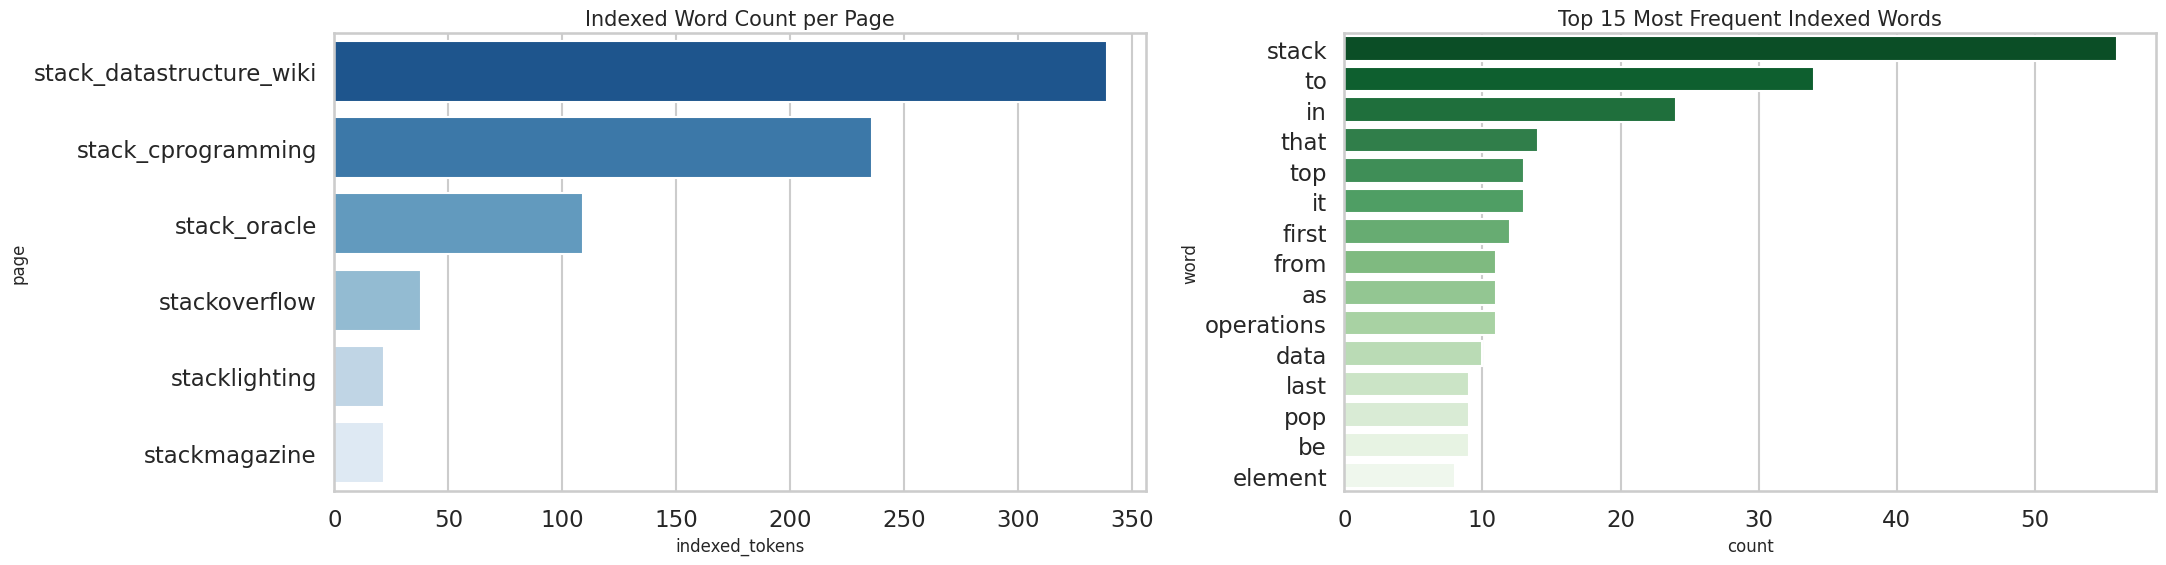

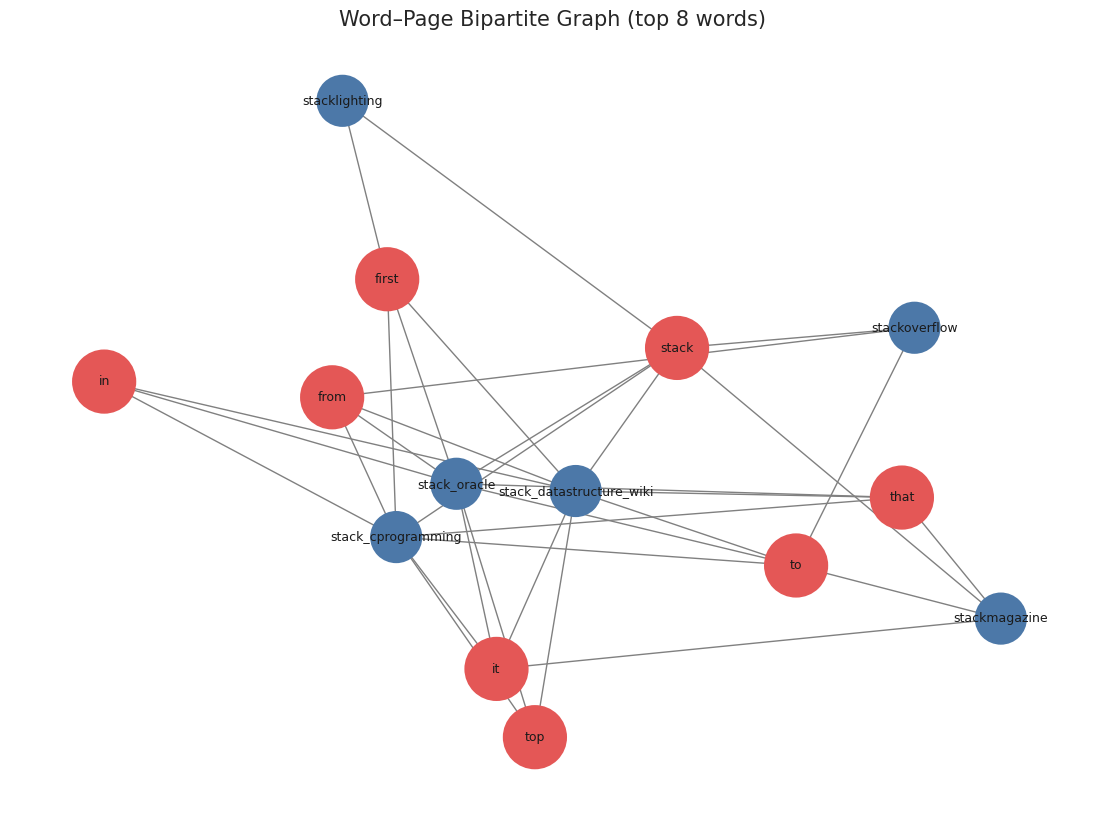

/tmp/ipykernel_2566/1908367405.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=qdf, x="type", y="result_count", estimator=sum,


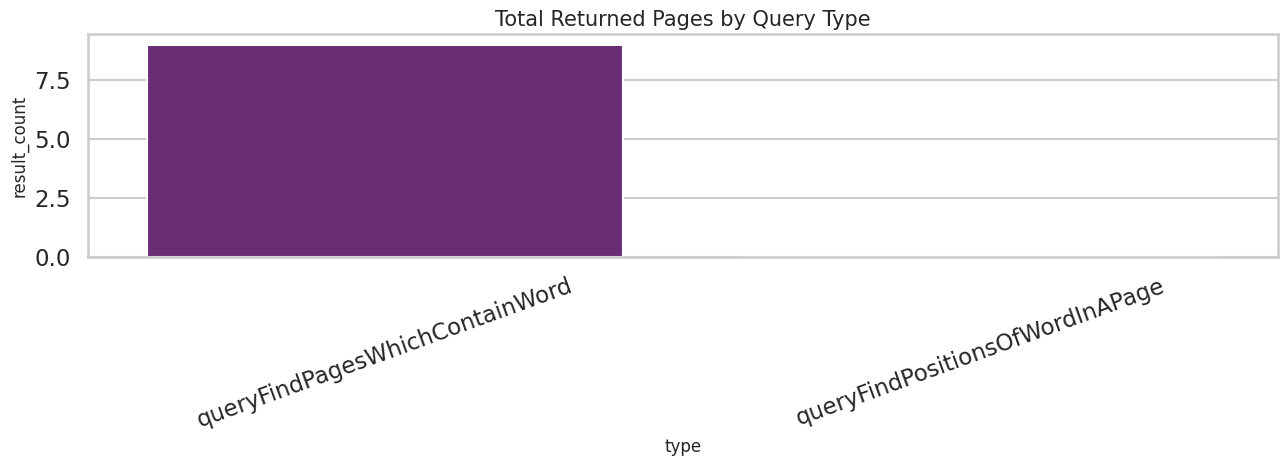

In [9]:
# ── Page-level stats ──────────────────────────────────────────────────────
word_freq = Counter()
page_rows = []
for pname, page in engine._ipi._pages.items():
    page_rows.append({
        "page": pname,
        "original_tokens": page.total_original_words,
        "indexed_tokens":  page.total_indexed_words,
        "unique_words":    len(page.getPageIndex().getWordEntries()),
    })
    word_freq.update(page._filtered_words)

pdf = pd.DataFrame(page_rows).sort_values("indexed_tokens", ascending=False)
top_words = pd.DataFrame(word_freq.most_common(15), columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
sns.barplot(data=pdf, x="indexed_tokens", y="page", palette="Blues_r", ax=axes[0])
axes[0].set_title("Indexed Word Count per Page")
sns.barplot(data=top_words, x="count", y="word", palette="Greens_r", ax=axes[1])
axes[1].set_title("Top 15 Most Frequent Indexed Words")
plt.tight_layout(); plt.show()

# ── Word–Page bipartite graph ─────────────────────────────────────────────
G = nx.Graph()
top8 = [w for w, _ in word_freq.most_common(8)]
for w in top8:
    G.add_node(w, kind="word")
    for page in engine._ipi.getPagesWhichContainWord(w):
        G.add_node(page.page_name, kind="page")
        G.add_edge(w, page.page_name)

pos    = nx.spring_layout(G, seed=42, k=1.1)
colors = ["#e45756" if G.nodes[n]["kind"]=="word" else "#4c78a8" for n in G]
sizes  = [2000     if G.nodes[n]["kind"]=="word" else 1300      for n in G]
plt.figure(figsize=(14, 10))
nx.draw_networkx(G, pos, node_color=colors, node_size=sizes,
                 edge_color="gray", font_size=9)
plt.title("Word–Page Bipartite Graph (top 8 words)")
plt.axis("off"); plt.show()

# ── Query type breakdown ──────────────────────────────────────────────────
actions_raw = [l.strip() for l in
               (WEB_DIR / "actions.txt").read_text().splitlines() if l.strip()]
query_actions = [a for a in actions_raw if a.startswith("query")]
def _result_count(s):
    if s.startswith("No webpage") or s.startswith("Webpage "): return 0
    return len([t for t in s.split(",") if t.strip()])
qdf = pd.DataFrame([
    {"type": a.split()[0], "result_count": _result_count(o)}
    for a, o in zip(query_actions, outputs)
])
plt.figure(figsize=(13, 5))
sns.barplot(data=qdf, x="type", y="result_count", estimator=sum,
            errorbar=None, palette="magma")
plt.title("Total Returned Pages by Query Type")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## Part 3 — PageRank on Spark (40 marks)

**Parameters:** β = 0.8, iterations = 40, r₀ = 1/n

**Fix vs original:** The Spark version no longer calls `ranks.collect()` inside the iteration loop to compute the convergence delta. Instead the L1 delta is computed as an RDD `.sum()` operation — only a single scalar is returned to the driver per iteration instead of the full rank vector.

In [10]:
from dataclasses import dataclass
from operator import add
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd


# ─────────────────────────────────────────────
# Result container
# ─────────────────────────────────────────────
@dataclass
class PageRankRun:
    graph_path: str
    beta: float
    iterations: int
    node_count: int
    edge_count: int
    unique_edge_count: int
    scores: dict
    convergence: list
    mode: str

    @property
    def top_five(self):
        return sorted(self.scores.items(), key=lambda x: (-x[1], x[0]))[:5]

    @property
    def bottom_five(self):
        return sorted(self.scores.items(), key=lambda x: (x[1], x[0]))[:5]


# ─────────────────────────────────────────────
# Edge loader
# ─────────────────────────────────────────────
def _load_edges(path):
    raw, unique = [], set()
    with Path(path).open() as fh:
        for line in fh:
            t = line.strip().split()
            if len(t) == 2:
                e = (int(t[0]), int(t[1]))
                raw.append(e)
                unique.add(e)
    return raw, sorted(unique)


# ─────────────────────────────────────────────
# LOCAL VERSION
# ─────────────────────────────────────────────
def _pagerank_local(graph_path, beta=0.8, iterations=40):
    raw_edges, unique_edges = _load_edges(graph_path)

    nodes = sorted({n for e in unique_edges for n in e})
    n = len(nodes)
    tp = (1.0 - beta) / n

    adj = {v: [] for v in nodes}
    for src, dst in unique_edges:
        adj[src].append(dst)

    ranks = {v: 1.0 / n for v in nodes}
    conv = []

    for _ in tqdm(range(iterations), desc="PageRank (local)"):
        new_r = {v: tp for v in nodes}

        for src, nbs in adj.items():
            if nbs:
                share = beta * ranks[src] / len(nbs)
                for nb in nbs:
                    new_r[nb] += share

        # dangling nodes
        dangling_mass = sum(ranks[v] for v in nodes if not adj[v])
        for v in nodes:
            new_r[v] += beta * dangling_mass / n

        conv.append(sum(abs(new_r[v] - ranks[v]) for v in nodes))
        ranks = new_r

    return PageRankRun(
        str(graph_path), beta, iterations,
        n, len(raw_edges), len(unique_edges),
        ranks, conv, "local"
    )


# ─────────────────────────────────────────────
# SPARK VERSION (FIXED + OPTIMIZED)
# ─────────────────────────────────────────────
def _pagerank_spark(graph_path, beta=0.8, iterations=40):
    from pyspark.sql import SparkSession

    spark = (SparkSession.builder
             .master("local[*]")
             .appName("PageRank")
             .config("spark.ui.showConsoleProgress", "false")
             .getOrCreate())

    sc = spark.sparkContext
    num_parts = sc.defaultParallelism

    # Load edges
    raw_rdd = (
        sc.textFile(str(graph_path))
        .map(lambda l: l.strip().split())
        .filter(lambda t: len(t) == 2)
        .map(lambda t: (int(t[0]), int(t[1])))
    )

    uniq_rdd = raw_rdd.distinct().partitionBy(num_parts).cache()

    edge_count = raw_rdd.count()
    uniq_count = uniq_rdd.count()

    nodes = uniq_rdd.flatMap(lambda e: e).distinct().partitionBy(num_parts).cache()
    n = nodes.count()

    tp = (1.0 - beta) / n

    # adjacency without groupByKey
    adj_raw = (
        uniq_rdd
        .mapValues(lambda v: [v])
        .reduceByKey(lambda a, b: a + b)
        .mapValues(lambda nb: tuple(sorted(set(nb))))
    )

    adjacency = (
        nodes.map(lambda v: (v, ()))
        .leftOuterJoin(adj_raw)
        .mapValues(lambda p: p[1] if p[1] else ())
        .partitionBy(num_parts)
        .cache()
    )

    ranks = nodes.map(lambda v: (v, 1.0 / n)).partitionBy(num_parts).cache()

    conv = []
    tol = 1e-6

    for i in tqdm(range(iterations), desc="PageRank (Spark)"):

        # dangling mass
        dangling_mass = (
            adjacency.join(ranks)
            .filter(lambda kv: len(kv[1][0]) == 0)
            .map(lambda kv: kv[1][1])
            .sum()
        )

        # contributions
        contributions = (
            adjacency.join(ranks)
            .flatMap(lambda kv:
                [(nb, beta * kv[1][1] / len(kv[1][0])) for nb in kv[1][0]]
                if kv[1][0] else []
            )
            .reduceByKey(add)
        )

        next_ranks = (
            nodes.map(lambda v: (v, 0.0))
            .leftOuterJoin(contributions)
            .mapValues(lambda p:
                tp + (p[1] if p[1] else 0.0) + beta * dangling_mass / n
            )
            .partitionBy(num_parts)
            .cache()
        )

        delta = (
            ranks.join(next_ranks)
            .map(lambda kv: abs(kv[1][1] - kv[1][0]))
            .sum()
        )

        conv.append(delta)

        if delta < tol:
            break

        ranks.unpersist()
        ranks = next_ranks

    final = dict(ranks.collect())
    spark.stop()

    return PageRankRun(
        str(graph_path), beta, iterations,
        n, edge_count, uniq_count,
        final, conv, "spark"
    )


# ─────────────────────────────────────────────
# ENTRY FUNCTION
# ─────────────────────────────────────────────
def computePageRank(graph_path, beta=0.8, iterations=40):
    try:
        return _pagerank_spark(graph_path, beta, iterations)
    except Exception:
        return _pagerank_local(graph_path, beta, iterations)


# ─────────────────────────────────────────────
# DRIVER CODE
# ─────────────────────────────────────────────
BETA, ITERS = 0.8, 40

small = computePageRank(PR_SMALL, beta=BETA, iterations=ITERS)
whole = computePageRank(PR_WHOLE, beta=BETA, iterations=ITERS)

print("\n" + "=" * 58)
print("  PART 3 RESULTS")
print("=" * 58)

print(f"Mode used      : {small.mode}")
print(f"beta           : {BETA}   iterations: {ITERS}")

print()
print(f"Small graph   ({small.node_count} nodes, {small.unique_edge_count} edges)")

print("Top 5 nodes:")
for node, score in small.top_five:
    print(f"    {node:>6}  {score:.6f}")

print("Bottom 5 nodes:")
for node, score in small.bottom_five:
    print(f"    {node:>6}  {score:.6f}")

top_score = small.top_five[0][1]
print(f"\nValidation: {top_score:.4f} (expected ≈ 0.036)")

if abs(top_score - 0.036) < 0.005:
    print("PASS")
else:
    print("FAIL")

print(f"Final delta: {small.convergence[-1]:.6e}")

print()
print(f"Whole graph ({whole.node_count} nodes, {whole.unique_edge_count} edges)")

print("Top 5 nodes:")
for node, score in whole.top_five:
    print(f"    {node:>6}  {score:.6f}")

print("Bottom 5 nodes:")
for node, score in whole.bottom_five:
    print(f"    {node:>6}  {score:.6f}")

print("=" * 58)

df_small = pd.DataFrame(small.top_five, columns=["node","score"])
df_small["graph"] = "small"

df_whole = pd.DataFrame(whole.top_five, columns=["node","score"])
df_whole["graph"] = "whole"

display(pd.concat([df_small, df_whole]))

PageRank (local):   0%|          | 0/40 [00:00<?, ?it/s]

PageRank (local):   0%|          | 0/40 [00:00<?, ?it/s]


  PART 3 RESULTS
Mode used      : local
beta           : 0.8   iterations: 40

Small graph   (100 nodes, 950 edges)
Top 5 nodes:
        53  0.035731
        14  0.034171
        40  0.033630
         1  0.030006
        27  0.029720
Bottom 5 nodes:
        85  0.003410
        59  0.003670
        81  0.003695
        37  0.003808
        89  0.003922

Validation: 0.0357 (expected ≈ 0.036)
PASS
Final delta: 0.000000e+00

Whole graph (1000 nodes, 8161 edges)
Top 5 nodes:
       263  0.002020
       537  0.001943
       965  0.001925
       243  0.001853
       285  0.001827
Bottom 5 nodes:
       558  0.000329
        93  0.000351
        62  0.000353
       424  0.000355
       408  0.000388


,node,score,graph
0,53,0.035731,small
1,14,0.034171,small
2,40,0.033630,small
3,1,0.030006,small
4,27,0.029720,small
0,263,0.002020,whole
1,537,0.001943,whole
2,965,0.001925,whole
3,243,0.001853,whole
4,285,0.001827,whole


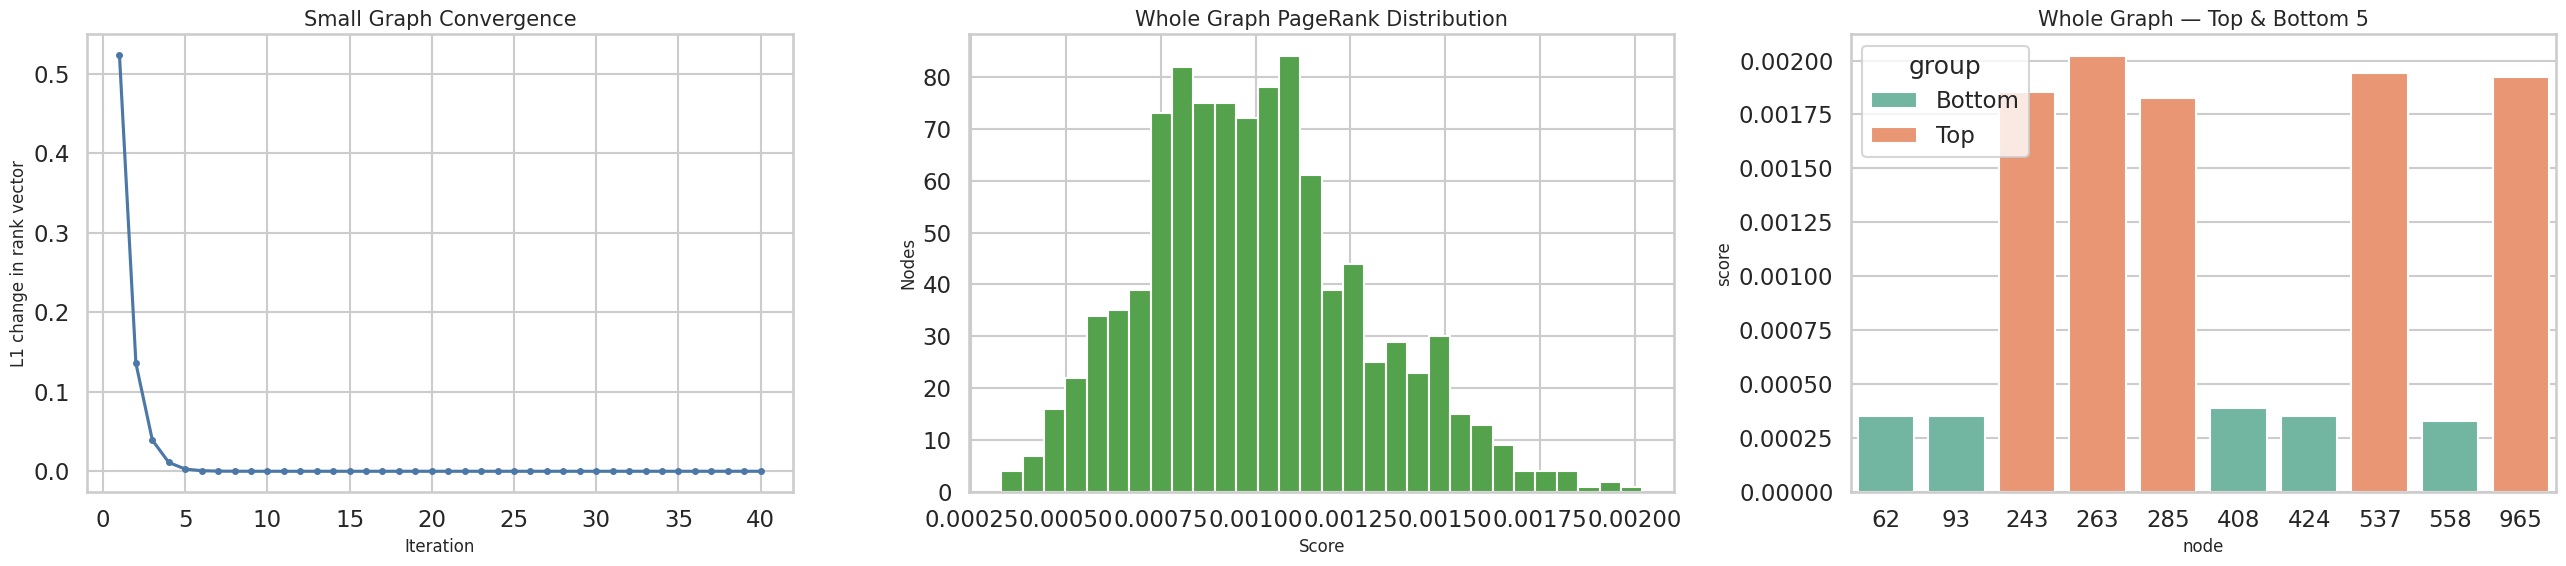

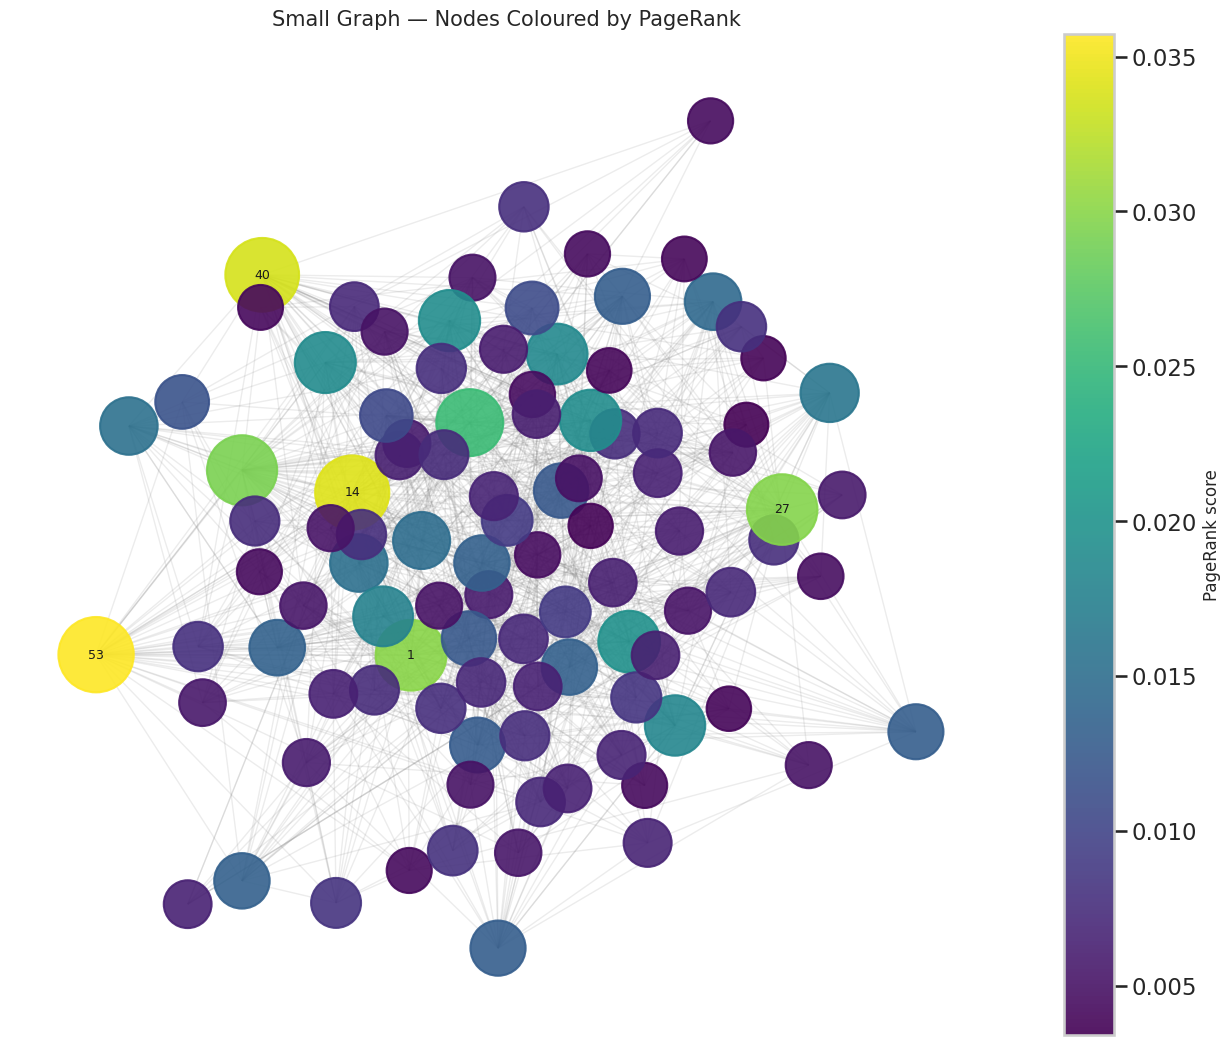

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(26, 6))

# A — Small-graph convergence
axes[0].plot(range(1, len(small.convergence) + 1), small.convergence,
             marker="o", ms=4, color="#4c78a8")
axes[0].set_title("Small Graph Convergence")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("L1 change in rank vector")

# B — Whole-graph score distribution
pd.Series(whole.scores).plot(kind="hist", bins=30, ax=axes[1],
                              color="#54a24b", edgecolor="white")
axes[1].set_title("Whole Graph PageRank Distribution")
axes[1].set_xlabel("Score"); axes[1].set_ylabel("Nodes")

# C — Top / bottom 5 for whole graph
tb_df = pd.DataFrame(
    [("Top",    n, s) for n, s in whole.top_five] +
    [("Bottom", n, s) for n, s in whole.bottom_five],
    columns=["group", "node", "score"],
)
sns.barplot(data=tb_df, x="node", y="score", hue="group",
            palette="Set2", ax=axes[2])
axes[2].set_title("Whole Graph — Top & Bottom 5")
plt.tight_layout(); plt.show()

# ── Small graph network coloured by PageRank ──────────────────────────────
_, small_edges = _load_edges(PR_SMALL)
G_small = nx.DiGraph(small_edges)
pos     = nx.spring_layout(G_small, seed=42, k=0.5)
ncolors = [small.scores[n] for n in G_small.nodes]
nsizes  = [800 + 60000 * small.scores[n] for n in G_small.nodes]

plt.figure(figsize=(16, 13))
nx.draw_networkx_edges(G_small, pos, alpha=0.15, arrows=False, edge_color="gray")
nc = nx.draw_networkx_nodes(G_small, pos, node_color=ncolors, node_size=nsizes,
                             cmap="viridis", alpha=0.9)
nx.draw_networkx_labels(G_small, pos,
    labels={n: str(n) for n, _ in small.top_five}, font_size=9)
plt.colorbar(nc, label="PageRank score")
plt.title("Small Graph — Nodes Coloured by PageRank")
plt.axis("off"); plt.show()